![Teste vocacional com Machine Learning](capa.png)

# Projeto - Teste Vocacional com Machine Learning
## Etapa 02 - Limpeza e Tratamento dos Dados

Nesta etapa, os problemas encontrados na exploração inicial (`01_coleta.ipynb`) serão tratados, e o resultado será salvo em `dados/Dados processados/` para ser usado nas próximas etapas.

**Entrada:** `dados/Dados originais/data.csv` (dado bruto, nunca alterado)

**Saída:** `dados/Dados processados/dados_limpos.csv`

O significado de cada coluna está documentado em `docs/codebook_ptbr.md`.

In [29]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python usada neste Projeto:', python_version())

Versão da Linguagem Python usada neste Projeto: 3.14.4


In [30]:
# Os pacotes deste projeto foram instalados no ambiente virtual (.venv),
# pelo terminal do VS Code, com o ambiente ativado:
#
#   .venv\Scripts\Activate.ps1
#   pip install pandas numpy matplotlib seaborn ipykernel watermark
#
# Depois de instalar ou atualizar um pacote, reinicie o kernel do notebook.

### Importando as bibliotecas necessárias

In [31]:
# Para manipulação dos dados - a dupla inseparável
import pandas as pd
import numpy as np

In [32]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Gustavo" --iversions

Author: Gustavo

matplotlib: 3.11.2
numpy     : 2.5.3
pandas    : 3.0.6
platform  : 1.0.9
re        : 2.2.1
seaborn   : 0.13.2



### Importação do conjunto de dados original

In [33]:
# Importando o dataset RIASEC original (separado por TAB)
df = pd.read_csv('../dados/Dados originais/data.csv', sep='\t', low_memory=False)

# Formato do dataset: (linhas, colunas)
df.shape

(145828, 94)

---
## 1. Renomeando as colunas para português

As colunas de códigos (`R1`...`C8`, `TIPI1`...`TIPI10`, `VCL1`...`VCL16`) mantêm os nomes originais, pois são siglas de instrumentos científicos. As demais são traduzidas seguindo o padrão *snake_case*, sem acentos.



In [34]:
#traduzindo as colunas para português 
traducao_colunas = {
    'orientation': 'orientacao_sexual',
    'engnat': 'ingles_nativo',
    'race': 'raca',
    'married': 'estado_civil',
    'religion': 'religiao',
    'voted': 'votou',
    'familysize': 'qtd_irmaos',
    'uniqueNetworkLocation': 'rede_unica',
    'country': 'pais',
    'source': 'origem_acesso',
    'major': 'curso',
    'introelapse': 'tempo_introducao',
    'testelapse': 'tempo_teste',
    'surveyelapse': 'tempo_pesquisa',
    'education': 'escolaridade',
    'urban': 'area_infancia',
    'gender': 'genero',
    'age': 'idade',
    'hand':'mao_dominante'

}
df = df.rename(columns=traducao_colunas)

In [35]:
# Conferindo se todas as colunas do dicionário foram renomeadas
# (se algum nome original estiver errado, ele continuará no DataFrame sem ser traduzido)
nao_renomeadas = [coluna for coluna in traducao_colunas if coluna in df.columns]

if nao_renomeadas:
    print('Atenção! Colunas não renomeadas:', nao_renomeadas)
else:
    print('Todas as', len(traducao_colunas), 'colunas foram renomeadas com sucesso!')


Todas as 19 colunas foram renomeadas com sucesso!


---
## 2. Resgatando o curso deslocado para a coluna fantasma

Na exploração, foi identificado que a coluna `Unnamed: 93` possui **um único valor**: o curso *economics* de um participante que digitou um TAB antes do nome do curso, deslocando o valor uma coluna para a direita. Esse valor será copiado para a coluna `curso`.

In [36]:
#Resgatando o curso que foi deslocado de coluna
filtro = df['Unnamed: 93'].notna()
df.loc[filtro, 'curso'] = df.loc[filtro, 'Unnamed: 93']
#conferindo se o valor foi resgatado
df.loc[filtro, ['curso', 'Unnamed: 93']]

,curso,Unnamed: 93
122158,economics,economics


---
## 3. Removendo a coluna fantasma

A coluna `Unnamed: 93` foi criada pelo TAB extra no final de cada linha do arquivo original. Após o resgate do único valor válido, ela pode ser removida.


In [37]:
#removendo coluna fantasma
df = df.drop(columns=['Unnamed: 93'])
#conferindo o resultado tem que dar 93 colunas
df.shape

(145828, 93)

In [38]:
df.head(15)

,R1,R2,R3,R4,R5,R6,R7,R8,I1,I2,...,religiao,orientacao_sexual,raca,votou,estado_civil,qtd_irmaos,rede_unica,pais,origem_acesso,curso
0,3,4,3,1,1,4,1,3,5,5,...,7,1,1,2,1,1,1,US,2,NaN
1,1,1,2,4,1,2,2,1,5,5,...,7,3,4,1,2,3,1,US,1,Nursing
2,2,1,1,1,1,1,1,1,4,1,...,7,1,4,2,1,1,1,US,1,NaN
3,3,1,1,2,2,2,2,2,4,1,...,0,1,1,2,1,1,1,CN,0,NaN
4,4,1,1,2,1,1,1,2,5,5,...,4,3,1,2,1,4,1,PH,0,education
5,3,5,1,3,1,5,3,4,4,5,...,2,1,5,1,1,2,1,IN,2,Literature
6,1,4,1,4,1,4,1,2,4,4,...,2,1,1,2,1,3,2,US,0,Math
7,5,1,2,2,2,1,2,1,4,4,...,7,3,1,2,1,0,1,PH,0,mathematics and science
8,1,1,1,1,1,1,1,1,2,1,...,4,1,1,1,1,3,1,US,0,family resource management
9,4,2,2,2,2,2,3,2,2,2,...,10,1,1,2,1,6,1,MY,1,Counselling


In [39]:
def relatorio_valores_ausentes_por_coluna(data):
    quant_valores_ausentes = data.isnull().sum()
    porcent_valores_ausentes = 100 * quant_valores_ausentes / len(data)
    tipo_de_dado = data.dtypes
    # axis=1 junta as três Series lado a lado, como colunas
    resumo_valores_ausentes = pd.concat([quant_valores_ausentes, porcent_valores_ausentes, tipo_de_dado], axis=1)
    #renomear as colunas 
    resumo_valores_ausentes.columns = ['Quantidade de Ausentes', 'Porcentagem de Ausentes', 'Tipo de Dado']
    # Remove as colunas sem valores ausentes e classifica em ordem decrescente por porcentagem de valores ausentes
    resumo_valores_ausentes = resumo_valores_ausentes[resumo_valores_ausentes['Quantidade de Ausentes'] > 0].sort_values('Porcentagem de Ausentes', ascending=False).round(2)
    # Exibe um resumo do relatório
    print(f"O conjunto de dados tem {data.shape[1]} colunas. \nForam encontradas {resumo_valores_ausentes.shape[0]} colunas com valores ausentes.")
    # Retorna o DataFrame com informações sobre valores ausentes por coluna
    return resumo_valores_ausentes

In [40]:
# Relatório de valores ausentes por coluna
relatorio_valores_ausentes_por_coluna(df)

O conjunto de dados tem 93 colunas. 
Foram encontradas 2 colunas com valores ausentes.


,Quantidade de Ausentes,Porcentagem de Ausentes,Tipo de Dado
curso,52873,36.26,str
pais,12,0.01,str


In [41]:
# Lista com os nomes das 48 colunas RIASEC: R1...R8, I1...I8, A1...A8, S1...S8, E1...E8, C1...C8
colunas_riasec = [f'{letra}{numero}' for letra in 'RIASEC' for numero in range(1, 9)]

# Conferindo
print(len(colunas_riasec), 'colunas:', colunas_riasec)


48 colunas: ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']


In [42]:
def relatorio_zeros_por_coluna(data, colunas):
    # (data[colunas] == 0) gera True onde o valor é zero; o .sum() conta os True de cada coluna
    quant_zeros = (data[colunas] == 0).sum()
    porcent_zeros = 100 * quant_zeros / len(data)
    # axis=1 junta as duas Series lado a lado, como colunas
    resumo_zeros = pd.concat([quant_zeros, porcent_zeros], axis=1)
    # Renomeia as colunas
    resumo_zeros.columns = ['Quantidade de Zeros', 'Porcentagem de Zeros']
    # Mantém só as colunas com zeros, da maior para a menor
    resumo_zeros = resumo_zeros[resumo_zeros['Quantidade de Zeros'] > 0].sort_values('Porcentagem de Zeros', ascending=False).round(2)
    # Exibe um resumo do relatório
    print(f"Das {len(colunas)} colunas analisadas, {resumo_zeros.shape[0]} possuem valores zero.")
    return resumo_zeros


In [43]:
# Relatório de zeros nas colunas RIASEC
relatorio_zeros_por_coluna(df, colunas_riasec)

Das 48 colunas analisadas, 48 possuem valores zero.


,Quantidade de Zeros,Porcentagem de Zeros
R5,746,0.51
A1,716,0.49
E1,711,0.49
R3,696,0.48
R7,672,0.46
A8,602,0.41
R8,590,0.40
A2,577,0.40
R4,568,0.39
E5,568,0.39


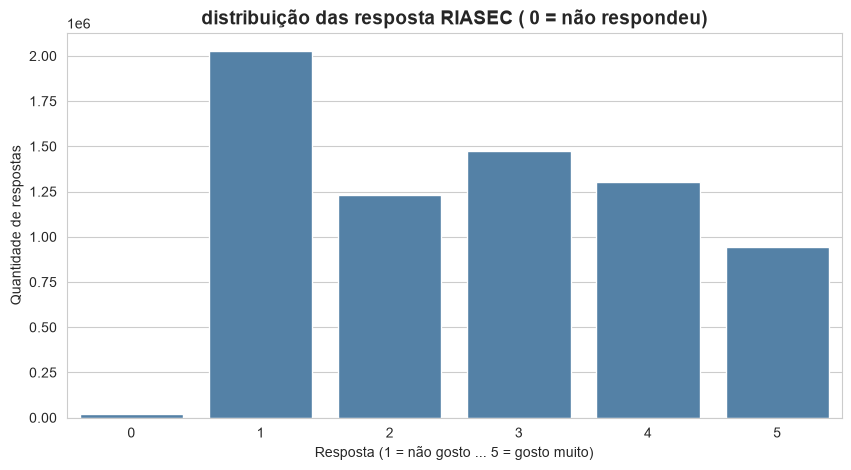

In [44]:
import matplotlib.pyplot as plt 
import seaborn as sns 
#juntando as respostas das 48 colunas em uma unica sequecia
respostas = df[colunas_riasec].values.flatten()

#grafico de barras com a quantidade de cada resposta (0 a 5)
sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))
sns.countplot(x=respostas, color='steelblue')
plt.title('distribuição das resposta RIASEC ( 0 = não respondeu)', fontsize=14, fontweight='bold')
plt.xlabel('Resposta (1 = não gosto ... 5 = gosto muito)')
plt.ylabel('Quantidade de respostas')
plt.show()

10064 participantes pularam pelo menos 1 pergunta (6.90% do total)


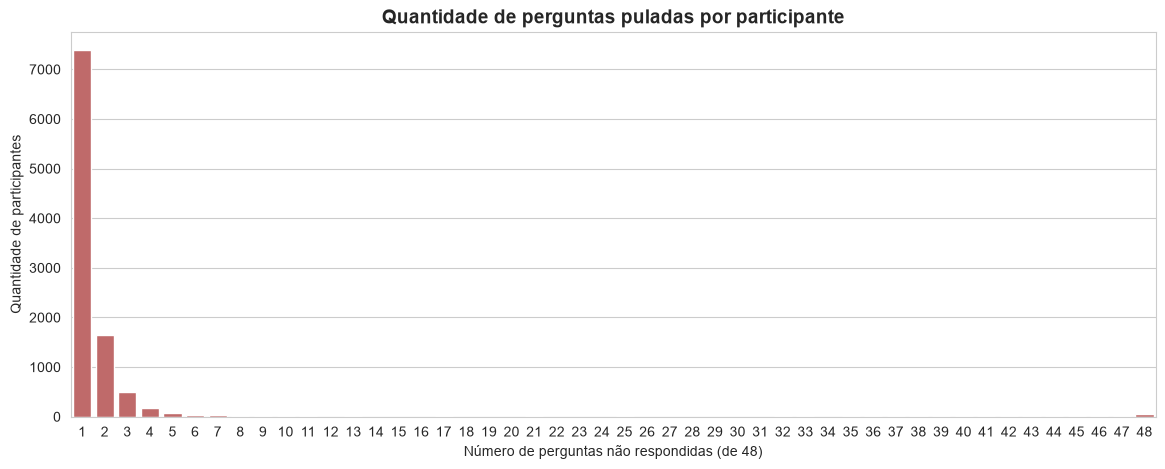

In [45]:
# Contando quantos zeros cada participante tem nas 48 perguntas (axis=1 → soma ao longo da linha)
zeros_por_pessoa = (df[colunas_riasec] == 0).sum(axis=1)

# Considerando apenas quem pulou pelo menos 1 pergunta
com_zeros = zeros_por_pessoa[zeros_por_pessoa > 0]
print(f'{len(com_zeros)} participantes pularam pelo menos 1 pergunta ({len(com_zeros) / len(df) * 100:.2f}% do total)')

# Gráfico de barras: quantas pessoas pularam 1, 2, 3... perguntas
plt.figure(figsize=(14, 5))
sns.countplot(x=com_zeros, color='indianred')
plt.title('Quantidade de perguntas puladas por participante', fontsize=14, fontweight='bold')
plt.xlabel('Número de perguntas não respondidas (de 48)')
plt.ylabel('Quantidade de participantes')
plt.show()


---
## 4. Tratando as perguntas RIASEC não respondidas (valores 0)

O codebook define a escala das respostas de **1 a 5**, mas os dados possuem valores **0**, que representam **perguntas não respondidas**.

Análise realizada:
- 10.064 participantes pularam pelo menos 1 pergunta, mas **73% deles pularam apenas 1**
- 61 participantes **não responderam nenhuma** das 48 perguntas
- Não há diferença relevante entre gêneros na quantidade de perguntas puladas

**Decisões:**
1. Remover participantes com **5 ou mais** perguntas não respondidas (mais de 10% do teste), pois o perfil fica incompleto. Isso representa apenas 0,25% da base.
2. Nos participantes restantes, substituir o 0 por **ausente (NaN)**, para que o "não respondeu" não seja tratado como uma nota baixa no cálculo dos escores.


In [46]:
#contando quantas perguntas RIASEC cada participante deixou sem resposta valor (0)
zero_por_pessoa = (df[colunas_riasec] == 0).sum(axis=1)
#conferencia de pessoas  que pularam N numeros de pergunta
zero_por_pessoa.value_counts().sort_index()

0     135764
1       7390
2       1652
3        489
4        172
5         72
6         36
7         26
8          7
9          7
10        10
11         5
12         3
13         4
14         2
15         1
16         3
17         4
18         1
19         1
20         1
21         4
22         2
23         3
24         2
25         5
26         3
27         1
28         2
29         3
30         2
31         2
32         4
33         4
34         1
35         5
36         5
37         6
38         4
39         5
40         8
41         5
42         6
43         6
44         5
45         4
46        11
47         9
48        61
Name: count, dtype: int64

In [47]:
#Limite de corte: participantes com mais de 5 perguntas sem responder >=10% será removido
limite_zeros = 5

#guardando a quantidade de linhas antes do tratamento para comparar depois
linhas_antes = len(df)

#mantendo apenas os participantes que pularem menos que o limite

df = df[zero_por_pessoa < limite_zeros]

#conferindo o resultado
print(f'linhas antes: {linhas_antes}')
print(f'linhas depois: {len(df)}')
print(f'participantes removidos: {linhas_antes - len(df)}')

linhas antes: 145828
linhas depois: 145467
participantes removidos: 361


In [48]:
#subistituindo os 0 por NAN apenas nas colunas RIASEC
df[colunas_riasec] = df[colunas_riasec].replace(0, np.nan)
# Conferência 1: não deve restar nenhum zero nas colunas RIASEC
relatorio_zeros_por_coluna(df, colunas_riasec)


Das 48 colunas analisadas, 0 possuem valores zero.


,Quantidade de Zeros,Porcentagem de Zeros


In [49]:
# Conferência 2: agora os antigos zeros aparecem como valores ausentes
relatorio_valores_ausentes_por_coluna(df)


O conjunto de dados tem 93 colunas. 
Foram encontradas 50 colunas com valores ausentes.


,Quantidade de Ausentes,Porcentagem de Ausentes,Tipo de Dado
curso,52735,36.25,str
A1,560,0.38,float64
R5,543,0.37,float64
E1,540,0.37,float64
R3,492,0.34,float64
R7,458,0.31,float64
A2,405,0.28,float64
A8,401,0.28,float64
R8,381,0.26,float64
R4,381,0.26,float64


---
## Próximos tratamentos

Problemas já identificados que ainda serão tratados nesta etapa:

- [ ] Valores absurdos em `idade` e `qtd_irmaos` (máximo de ~2,1 bilhões)
- [ ] Respostas inválidas: participantes que marcaram as palavras inventadas (`VCL6`, `VCL9`, `VCL12`)
- [ ] Possíveis duplicatas (`rede_unica = 2`)
- [ ] Padronização da coluna `curso` (texto livre, com muitas grafias diferentes)

---
## 5. Removendo respostas inválidas (palavras inventadas)

As colunas `VCL6`, `VCL9` e `VCL12` são palavras que **não existem** (*cuivocal*, *florted*, *verdid*). Quem afirmou conhecê-las demonstrou desatenção ou falta de sinceridade.

**Decisão:** remover quem marcou **2 ou mais** palavras inventadas. Marcar apenas 1 pode ser confusão com uma palavra parecida, mas marcar 2 ou 3 indica um padrão de respostas pouco confiáveis.


In [50]:
# Colunas das palavras inventadas (verificação de validade)
palavras_inventadas = ['VCL6', 'VCL9', 'VCL12']

# Quantas palavras inventadas cada participante marcou (0 a 3)
qtd_palavras_inventadas = df[palavras_inventadas].sum(axis=1)
print(qtd_palavras_inventadas.value_counts().sort_index())

# Limite de corte: 2 ou mais palavras inventadas → resposta inválida
limite_palavras_inventadas = 2

linhas_antes = len(df)
df = df[qtd_palavras_inventadas < limite_palavras_inventadas]
print(f'Participantes removidos: {linhas_antes - len(df)} | Restantes: {len(df)}')


0    116287
1     21897
2      5324
3      1959
Name: count, dtype: int64
Participantes removidos: 7283 | Restantes: 138184


---
## 6. Tratando valores absurdos em `idade` e `qtd_irmaos`

Foram encontrados valores impossíveis, como idades de 666, 1997 e 2.147.483.647 (o maior número inteiro que um computador de 32 bits consegue armazenar, provavelmente o limite do campo do formulário).

**Decisão:** essas colunas **não serão usadas no modelo**, então os participantes **não serão removidos**: apenas os valores inválidos serão transformados em ausentes (`NaN`), preservando as respostas RIASEC dessas pessoas.

- `idade`: válida entre 13 e 100 anos
- `qtd_irmaos`: válida entre 1 e 20 (a pergunta inclui a própria pessoa, então o mínimo é 1)


In [51]:
# Identificando idades fora do intervalo válido (13 a 100 anos)
# O | significa "OU": a idade é inválida se for menor que 13 OU maior que 100
idade_invalida = (df['idade'] < 13) | (df['idade'] > 100)
print(f'Idades inválidas: {idade_invalida.sum()}')

# Substituindo as idades inválidas por NaN
df.loc[idade_invalida, 'idade'] = np.nan

# Mesmo tratamento para a quantidade de filhos da mãe (1 a 20)
irmaos_invalido = (df['qtd_irmaos'] < 1) | (df['qtd_irmaos'] > 20)
print(f'Quantidades de irmãos inválidas: {irmaos_invalido.sum()}')
df.loc[irmaos_invalido, 'qtd_irmaos'] = np.nan

# Conferindo: os máximos agora devem ser 100 e 20
df[['idade', 'qtd_irmaos']].describe()


Idades inválidas: 72
Quantidades de irmãos inválidas: 4090


,idade,qtd_irmaos
count,138112.000000,134094.000000
mean,25.821565,2.896334
std,11.784843,1.522553
min,13.000000,1.000000
25%,17.000000,2.000000
50%,21.000000,3.000000
75%,31.000000,3.000000
max,100.000000,20.000000


---
## 7. Verificando duplicatas

A coluna `rede_unica = 2` indica mais de um registro vindo da mesma rede de internet. Isso **não significa duplicata**: escolas, universidades e empresas compartilham a mesma rede. Por isso esses registros serão **mantidos**.

Verifica-se apenas se existem linhas **completamente idênticas**.


In [52]:
# Verificando linhas completamente idênticas
print(f'Linhas duplicadas: {df.duplicated().sum()}')

# Distribuição dos registros por rede
df['rede_unica'].value_counts()


Linhas duplicadas: 0


rede_unica
1    95689
2    42495
Name: count, dtype: int64

---
## 8. Filtrando participantes que informaram o curso

A coluna `curso` é o **alvo** do modelo: é o que ele vai aprender a prever. Participantes sem curso informado não servem para o treinamento supervisionado.


In [53]:
# Mantendo apenas os participantes que informaram o curso
linhas_antes = len(df)
df = df[df['curso'].notna()]
print(f'Participantes removidos: {linhas_antes - len(df)} | Restantes: {len(df)}')


Participantes removidos: 50122 | Restantes: 88062


---
## 9. Padronizando o texto da coluna `curso`

O curso foi digitado livremente, gerando milhares de variações para o mesmo curso ("Psychology", "psychology ", "PSYCHOLOGY!"). O texto é padronizado para minúsculas, sem pontuação e sem espaços extras. A coluna original é mantida, e a versão padronizada vai para uma coluna nova.


In [54]:
# Quantidade de cursos diferentes ANTES da padronização
print(f'Cursos únicos antes: {df["curso"].nunique()}')

# Padronizando o texto do curso, passo a passo
df['curso_padronizado'] = (df['curso']
                           .str.lower()                                     # tudo minúsculo
                           .str.replace(r'[^a-z ]', ' ', regex=True)        # troca o que não for letra por espaço
                           .str.replace(r'\s+', ' ', regex=True)            # junta espaços repetidos em um só
                           .str.strip())                                    # remove espaços do início e do fim

# Quantidade de cursos diferentes DEPOIS da padronização
print(f'Cursos únicos depois: {df["curso_padronizado"].nunique()}')

# Os 20 cursos mais frequentes
df['curso_padronizado'].value_counts().head(20)


Cursos únicos antes: 15176
Cursos únicos depois: 10611


curso_padronizado
psychology                 13169
business                    3654
english                     3019
nursing                     2232
biology                     1990
education                   1849
engineering                 1443
accounting                  1245
computer science            1194
law                         1057
civil engineering           1056
economics                   1056
history                      926
marketing                    894
sociology                    876
criminal justice             870
management                   812
business administration      784
finance                      753
medicine                     750
Name: count, dtype: int64

---
## 10. Agrupando os cursos em áreas de formação

Prever entre 10 mil cursos diferentes é inviável. Os cursos são agrupados nas **áreas gerais da classificação CINE Brasil (INEP)**, a partir de palavras-chave. Isso também resolve erros de digitação comuns (ex.: "psycology", "buisness").

- As regras são verificadas **em ordem**, e a primeira que combinar define a área. Por isso, as regras mais específicas vêm primeiro (ex.: "computer engineering" deve cair em Computação antes de a palavra "engineering" levá-lo para Engenharia).
- Respostas que não são cursos ("no", "none", "undecided") são marcadas como **Sem curso**.
- Cursos que nenhuma regra reconheceu são marcados como **Não classificado**.
- Ambos são removidos da base de treino.


In [55]:
import re

# Dicionário: área de formação (CINE Brasil) -> padrão de palavras-chave (expressão regular)
# A ORDEM IMPORTA: a primeira área cujo padrão for encontrado no curso é a escolhida
mapa_areas = {
    'Sem curso': r'^(no|none|n a|na|nothing|other|undecided|undeclared|not applicable|nope|null|x|unknown|idk|yes|high school|senior high school|not sure|never|nil|n|no major|not yet|general|general studies)$|^(i )?(did not|didn t|didnt|have not|haven t|havent|never|dont|don t) ',
    'Computação e TIC': r'comput|\bit\b|\bict\b|\bmis\b|information tech|software|informatic|information system|data science|\bcs\b|programming|cyber|networking',
    'Engenharia, produção e construção': r'engin|architect|construction|mechatronic|electronic|manufactur|automotive|aeronaut|petroleum|mining|urban planning|surveying|food tech|industrial tech|welding|mechanics|^(civil|mechanical|electrical)$',
    'Saúde e bem-estar': r'nurs|medic|pre med|doctor|pharm|dentist|dental|health|physiolog|physiother|physical therap|occupational|kinesiol|nutrition|dietet|mbbs|surg|optom|radiolog|paramedic|social work|social services|rehab|recreation|midwif|speech|veterinar|sport|exercise|athletic',
    'Negócios, administração e direito': r'b\w*s\w*ness|account|\bcpa\b|financ|\becon|\bbba\b|market|advertis|manag|commerce|\blaw|legal|juris|human resource|\bhrm?\b|administra|\bmba\b|entrepreneur|banking|real estate|insurance|logistic|supply chain|paralegal|hospitality|tourism|leadership',
    'Ciências sociais, comunicação e informação': r'ps\w*chol|\bpsy|\bpys|\bpsc|\bpych|psic|psik|phych|sociol|politic|government|public policy|anthropol|international|global studies|asian studies|communica|journal|media|geograph|social science|public relations|criminol|library|counsel|human servic|human relations|criminal|human development|child development|family studies|gender stud|social stud',
    'Ciências naturais, matemática e estatística': r'biolog|\bbio|chemi|physic|math|statist|science|zoolog|ecolog|environment|geolog|marine|astronom|neuro|genetic|microbio|botan|forensic',
    'Educação': r'educat|teach|pedagog|early child',
    'Artes e humanidades': r'\barts?\b|english|histor|archaeolog|philosoph|music|design|illustrat|literat|language|linguist|translat|theat|acting|theolog|relig|biblical|ministry|film|cinema|writing|french|spanish|german|russian|chinese|japanese|filipino|philolog|dance|fashion|photograph|humanit|liberal|classic|creative|animation|drama|culinary|american studies',
    'Agricultura e veterinária': r'agric|forest|agronom|animal science|horticult',
    'Serviços': r'hotel|police|fire|military|security|aviation|pilot|cosmetol|beauty',
}


In [56]:
def mapear_area(curso):
    # Percorre as áreas na ordem do dicionário
    for area, padrao in mapa_areas.items():
        # re.search procura o padrão em qualquer parte do texto do curso
        if re.search(padrao, curso):
            return area
    # Nenhum padrão encontrado
    return 'Não classificado'


# Testando a função com alguns exemplos antes de aplicar em tudo
for exemplo in ['psychology', 'psycology', 'computer engineering', 'civil engineering', 'it', 'politics', 'none']:
    print(f'{exemplo:25} -> {mapear_area(exemplo)}')


psychology                -> Ciências sociais, comunicação e informação
psycology                 -> Ciências sociais, comunicação e informação
computer engineering      -> Computação e TIC
civil engineering         -> Engenharia, produção e construção
it                        -> Computação e TIC
politics                  -> Ciências sociais, comunicação e informação
none                      -> Sem curso


In [57]:
# Aplicando a função a cada curso padronizado
df['area'] = df['curso_padronizado'].apply(mapear_area)

# Quantidade de participantes por área
print(df['area'].value_counts())

# Cursos mais frequentes que não foram classificados (para melhorar o dicionário no futuro)
df[df['area'] == 'Não classificado']['curso_padronizado'].value_counts().head(20)


area
Ciências sociais, comunicação e informação     23378
Negócios, administração e direito              16719
Artes e humanidades                            11046
Saúde e bem-estar                               9015
Ciências naturais, matemática e estatística     7583
Engenharia, produção e construção               7100
Não classificado                                4397
Computação e TIC                                3323
Educação                                        3195
Sem curso                                       1973
Serviços                                         192
Agricultura e veterinária                        141
Name: count, dtype: int64


curso_padronizado
                             252
interdisciplinary studies     44
technology                    39
stem                          23
social                        18
aa                            12
town planning                 12
broadcasting                  12
european studies              11
meteorology                   11
still in high school          11
cultural studies              11
italian                       10
chef                          10
tesl                          10
aerospace                     10
justice studies               10
unsure                        10
radiography                   10
ba                            10
Name: count, dtype: int64

In [58]:
# Removendo participantes sem curso válido ou com curso não classificado
linhas_antes = len(df)
df = df[~df['area'].isin(['Sem curso', 'Não classificado'])]
print(f'Participantes removidos: {linhas_antes - len(df)} | Restantes: {len(df)}')


Participantes removidos: 6370 | Restantes: 81692


---
## 11. Calculando os escores das 6 dimensões RIASEC

Cada dimensão recebe um escore igual à **média das perguntas respondidas** pelo participante naquela dimensão. Os valores ausentes (perguntas puladas) são ignorados no cálculo, sem imputação. Como foram removidos os participantes com 5 ou mais perguntas puladas, toda dimensão tem pelo menos 4 respostas, e nenhum escore fica vazio.

Esses 6 escores serão as **variáveis de entrada** do modelo.


In [59]:
# As 6 dimensões do modelo de Holland
dimensoes = {
    'R': 'Realista',
    'I': 'Investigativo',
    'A': 'Artístico',
    'S': 'Social',
    'E': 'Empreendedor',
    'C': 'Convencional',
}

# Para cada dimensão, calcula a média das suas 8 perguntas (o NaN é ignorado automaticamente)
for letra in dimensoes:
    colunas_da_dimensao = [f'{letra}{numero}' for numero in range(1, 9)]
    df[f'escore_{letra}'] = df[colunas_da_dimensao].mean(axis=1)

# Lista com os nomes das colunas de escore, para usar depois
colunas_escores = [f'escore_{letra}' for letra in dimensoes]

# Conferência 1: nenhum escore pode estar vazio
print(f'Escores vazios: {df[colunas_escores].isnull().sum().sum()}')

# Conferência 2: os escores devem ficar entre 1 e 5
df[colunas_escores].describe().round(2)


Escores vazios: 0


,escore_R,escore_I,escore_A,escore_S,escore_E,escore_C
count,81692.00,81692.00,81692.00,81692.00,81692.00,81692.00
mean,2.10,3.03,2.94,3.39,2.59,2.44
std,0.88,1.03,1.00,0.88,0.88,0.98
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.38,2.25,2.14,2.88,1.88,1.62
50%,2.00,3.12,3.00,3.50,2.62,2.38
75%,2.75,3.88,3.75,4.00,3.25,3.12
max,5.00,5.00,5.00,5.00,5.00,5.00


---
## Salvando o dataset tratado

> ⚠️ Esta célula deve ser executada **somente ao final**, depois de todos os tratamentos.

In [60]:
# Resumo final da limpeza
print(f'Dataset final: {df.shape[0]} participantes e {df.shape[1]} colunas')

# Salvando o dataset tratado na pasta de dados processados
df.to_csv('../dados/Dados processados/dados_limpos.csv', index=False)
print('Arquivo salvo com sucesso!')


Dataset final: 81692 participantes e 101 colunas
Arquivo salvo com sucesso!
